In [1]:
#import gwpy
import copy
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import numpy as np
import astropy.units as u
import astropy.cosmology
from matplotlib import pyplot as plt
import swyft
from sklearn.preprocessing import StandardScaler
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning import loggers as pl_loggers
import torch
from astropy.cosmology import Planck18, z_at_value, Planck13, Planck15
from scipy.integrate import quad
from scipy import interpolate
from astropy.constants import pc, c
import scipy
import jax
from jaxinterp2d import interp2d
import seaborn as sns
from jax import jit
import jax.numpy as jnp
from jax import device_get
import numpyro
import arviz as az
import numpyro.distributions as dist
from gwpy.timeseries import TimeSeries
from numpyro.infer import MCMC, NUTS
import torch.nn as nn
import torch.nn.functional as F
np.random.seed(3407)
import pickle


/home/lexi.leali/.conda/envs/SBI_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lexi.leali/.conda/envs/SBI_env/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
# Define simulator parameters
f_low = 10
f_high = 200
Delta_f = 1./32
N_bins = int((f_high-f_low)/Delta_f) + 1
freq = np.linspace(f_low, f_high+Delta_f, N_bins)
pi = np.pi
sqrt = np.sqrt
H100 = 3.241e-18
h    = 0.679
H0   = h * H100

# Define Simulator
class Simulator(swyft.Simulator):
    def __init__(self, fref, psd, gamma, T_obs, Nbins=len(freq), bounds=None):
        super().__init__()
        self.fref      = fref
        self.psd       = psd
        self.gamma     = gamma
        self.T_obs     = T_obs
       
    

        self.transform_samples = swyft.to_numpy32
        self.Nbins = Nbins
        self.freq = np.linspace(f_low, f_high, N_bins)
        self.sample_z = swyft.RectBoundSampler([stats.uniform(-15, 7),
                                                stats.uniform(-5,10)], #alpha
                                                bounds = bounds) #bounds changes range of the prior

    def psd_interp(self):
        return scipy.interpolate.interp1d(self.psd[:,0], self.psd[:,1])(self.freq)
    
    def gamma_interp(self):
        return scipy.interpolate.interp1d(self.gamma[:, 0], self.gamma[:, 1])(self.freq)
    
    def sigma(self):
        numerator = (20*pi**2*self.freq**3)**2 * self.psd_interp()**2
        denomenator = (3*H0**2)**2 * 8*self.gamma_interp()**2
        #denomenator = (3*H0**2)**2 * 8
        T = 1/(self.freq[1]-self.freq[0])
        N = 2*self.T_obs // T - 1
        return np.sqrt(numerator/denomenator/N)
    
    def C_groundtruth(self, z):
        Omega_ref = 10** z[0]

        alpha     = z[1]
        C_hat_ij = Omega_ref * (self.freq/self.fref)**alpha
        return C_hat_ij
    
    def build(self, graph):
        z = graph.node('z', self.sample_z)
        m = graph.node('m', self.C_groundtruth, z)
        x = graph.node("x", lambda m: m + np.random.normal(0, self.sigma()), m)
        sigma = graph.node('sigma',self.sigma)

In [3]:
def preprocess_whiten(y_raw, sigma_raw):
    """
    y_raw: (batch_size, 4096)
    sigma_raw: (4096,) or (batch_size, 4096)
    """

    # 1. Whitening
    #weight = sigma_raw**-2/(np.sum(sigma_raw**-2))
    y_whitened = y_raw# * weight

    # 2. Log compression 
    y_log = np.log10(np.abs(y_whitened)/sigma_raw)
   
    return y_log

In [4]:
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.block(x)



class AE(swyft.SwyftModule,swyft.AdamWReduceLROnPlateau):
    def __init__(self, lr = 1e-6, gamma=0.98, weight_decay=1e-5, lr_scheduler_factor=0.1):
        super().__init__()
        
        marginals = ((0,1), )
        self.learning_rate = lr
        self.lr_scheduler_factor = lr_scheduler_factor
        self.weight_decay = weight_decay
        self.gamma = gamma
        # AE-Summarizer
       
        self.summarizer = nn.Sequential(

            nn.Linear(2048, 1024),  nn.GELU(),
            ResBlock(1024),  nn.GELU(),
    
            nn.Linear(1024, 256),  nn.GELU(),
            ResBlock(256),  nn.GELU(),

            #nn.Linear(512, 256),  nn.GELU(),
            #ResBlock(256),  nn.GELU(),

            #nn.Linear(256, 128),  nn.GELU(),
            #ResBlock(128),  nn.GELU(),
        
            nn.Linear(256, 64), nn.GELU(),
            ResBlock(64),  nn.GELU(),
        
            nn.Linear(64, 16),  nn.GELU(),
            ResBlock(16),  nn.GELU(),

            nn.Linear(16, 8),  nn.GELU(),
            ResBlock(8),  nn.GELU(),

            #nn.Linear(8, 4),  nn.GELU(),
            #ResBlock(4), nn.GELU()
        )

        
    
        self.logratios_1D = swyft.LogRatioEstimator_1dim(
            num_features=8,  # Number of features in compressed x (simulated observation)
            num_params=2,    # Two parameters to infer: alpha and omega
            varnames='z', 
            dropout = 0# Names of the parameters
            # Number of neural network blocks
        )
            
        self.logratios_2D = swyft.LogRatioEstimator_Ndim(num_features =8, 
                                                       marginals = marginals, varnames = 'z', num_blocks = 4,  dropout = 0)
        
            
    def forward(self, A, B):
        s = self.summarizer(A['x'])

        return self.logratios_1D(s, B['z']),  s, self.logratios_2D(s, B['z'])

In [5]:
def preprocess_observation(alpha, omega):
    test_data = sim.sample(conditions={'z':[omega, alpha]}
                    )
    original_test_data = copy.deepcopy(test_data['x'])
    test_data['x'] = test_data['x'].reshape([1, 2048])
    test_data['x'] = preprocess_whiten(test_data['x'] , sigma)
    test_data['x'] = test_data['x'][0]
    # Save this test data to make sure we have exactly the same obs
    np.savez("./omega" + str(omega) + "alpha" + str(alpha) + "_data.npz", original_test_data = original_test_data, test_data_x=test_data['x'],
            test_data_z=test_data['z'])
    saved_test_data = np.load("./omega" + str(omega) + "alpha" + str(alpha) + "_data.npz")
    test_data['x'] = saved_test_data['test_data_x']
    test_data['z'] = saved_test_data['test_data_z']
    original_test_data = saved_test_data['original_test_data']

    return test_data, original_test_data

In [6]:

class AEVisualizer:
    def __init__(self, model, device="cpu"):
        self.model = model.to(device)
        self.device = device

    # ---------- A. Summarizer diagnostics ----------
    def plot_feature_histograms(self, x, n_bins=50):
        """Plot histograms of compressed features."""
        self.model.eval()
        with torch.no_grad():
            features = self.model.summarizer(x.to(self.device)).cpu().numpy()

        fig, axes = plt.subplots(1, features.shape[1], figsize=(4*features.shape[1], 3))
        for i in range(features.shape[1]):
            axes[i].hist(features[:, i], bins=n_bins, color="steelblue", alpha=0.7)
            axes[i].set_title(f"Feature {i}")
        plt.tight_layout()
        plt.show()
        return features

    def plot_feature_correlation(self, features):
        """Correlation heatmap of compressed features."""
        df = pd.DataFrame(features, columns=[f"f{i}" for i in range(features.shape[1])])
        plt.figure(figsize=(6,5))
        sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
        plt.title("Feature Correlation Heatmap")
        plt.show()

    def plot_features_vs_params(self, features, params, param_names=( "omega", "alpha")):
        """Scatter plots of features vs. parameters."""
        n_params = params.shape[1]
        for j in range(n_params):
            for i in range(features.shape[1]):
                plt.scatter(features[:, i], params[:, j], s=5, alpha=0.5)
                plt.xlabel(f"Feature {i}")
                plt.ylabel(param_names[j])
                plt.show()

    
    def plot_3d_features(self, features, params, param_names=( "omega", "alpha")):

        n_params = params.shape[1]
        for f in range(features.shape[1]):
            feat = features[:, f]
            fig = plt.figure(figsize=(8,6))
            ax = fig.add_subplot(111, projection="3d")
            sc = ax.scatter(params[:,1], params[:,0], feat, c=feat, cmap="plasma", alpha=0.7)
            ax.set_xlabel("Alpha")
            ax.set_ylabel("Omega")
            ax.set_zlabel(f"Feature {f}")
            fig.colorbar(sc, label=f"Feature {f}")
            plt.title(f"Alpha–Omega–Feature {f}")
            plt.show()

    # ---------- B. LogRatio diagnostics ----------
    def plot_corner(self, posterior_samples, truths=None, labels=(r"$\alpha$", r"$\omega$")):
        """Corner plot of posterior samples."""
        samples = posterior_samples.cpu().numpy() if torch.is_tensor(posterior_samples) else posterior_samples
        fig = corner.corner(samples, labels=labels, truths=truths)
        plt.show()

    def plot_logratio_histogram(self, logratios_matched, logratios_mismatched, n_bins=50):
        """Compare distributions of log ratios for matched vs mismatched pairs."""
        plt.hist(logratios_matched, bins=n_bins, alpha=0.6, label="Matched", density=True)
        plt.hist(logratios_mismatched, bins=n_bins, alpha=0.6, label="Mismatched", density=True)
        plt.xlabel("Log Ratio")
        plt.ylabel("Density")
        plt.legend()
        plt.title("Log Ratio Distributions")
        plt.show()

    # ---------- C. Coverage check ----------
    def coverage_check(self, posterior_samples, true_params, levels=[0.5, 0.9]):
        """
        Quick coverage diagnostic: 
        For each credible interval, check fraction of times truth lies inside.
        posterior_samples: [N, n_params]
        true_params: [N, n_params]
        """
        posterior = posterior_samples.cpu().numpy() if torch.is_tensor(posterior_samples) else posterior_samples
        truths = true_params.cpu().numpy() if torch.is_tensor(true_params) else true_params

        results = {}
        for level in levels:
            count = 0
            for s, t in zip(posterior, truths):
                lo = np.quantile(s, (1-level)/2, axis=0)
                hi = np.quantile(s, 1-(1-level)/2, axis=0)
                inside = np.all((t >= lo) & (t <= hi))
                count += int(inside)
            results[level] = count / len(truths)

        print("Coverage results:")
        for k, v in results.items():
            print(f" {int(k*100)}% CI: {v:.2f}")
        return results


In [7]:
# Define simulator parameters
f_low = 10
f_high = 200
N_bins = 2048
freq = np.linspace(f_low, f_high, N_bins)
pi = np.pi
sqrt = np.sqrt
H100 = 3.241e-18
h    = 0.679
H0   = h * H100

# Sample from Simulator

fref = 25
CE_PSD = np.genfromtxt("data/cosmic_explorer_40km_for_paper.txt")
CE_PSD[0, 0]  = 4.99999999999999999
CE_PSD[:, 1] = CE_PSD[:, 1]**2
gamma_HL = np.genfromtxt("data/gamma_HL.txt")
T_obs = 365 * 24 * 3600

### Load pretrained model and data here

In [8]:
"""
saved_test_data = np.load("./omega-8.5alpha1.5_data.npz")
test_data = {"x":[], "z":[]}
test_data["x"] = saved_test_data['test_data_x']
test_data["z"]= saved_test_data['test_data_z']
original_test_data = saved_test_data['original_test_data']
"""

'\nsaved_test_data = np.load("./omega-8.5alpha1.5_data.npz")\ntest_data = {"x":[], "z":[]}\ntest_data["x"] = saved_test_data[\'test_data_x\']\ntest_data["z"]= saved_test_data[\'test_data_z\']\noriginal_test_data = saved_test_data[\'original_test_data\']\n'

In [9]:

"""
 # Open the file in binary read mode ('rb')
with open("TMNRE_round_1.pkl", 'rb') as file:
        # Load the pickled data
        loaded_data = pickle.load(file)

neg_bounds_rounds = loaded_data["neg_bounds"]
neg_samples_rounds = loaded_data["neg_samples"]
neg_predictions_rounds = loaded_data["neg_predictions"]
pos_bounds_rounds = loaded_data[ "pos_bounds"]
pos_samples_rounds = loaded_data["pos_samples"]
pos_predictions_rounds = loaded_data["pos_predictions"]
zero_bounds_rounds = loaded_data["zero_bounds"]
zero_samples_rounds = loaded_data["zero_samples"]
zero_predictions_rounds = loaded_data[ "zero_predictions"]
noise_bounds_rounds = loaded_data[ "noise_bounds"]
noise_samples_rounds = loaded_data["noise_samples"]
noise_predictions_rounds = loaded_data["noise_predictions"]
"""

'\n # Open the file in binary read mode (\'rb\')\nwith open("TMNRE_round_1.pkl", \'rb\') as file:\n        # Load the pickled data\n        loaded_data = pickle.load(file)\n\nneg_bounds_rounds = loaded_data["neg_bounds"]\nneg_samples_rounds = loaded_data["neg_samples"]\nneg_predictions_rounds = loaded_data["neg_predictions"]\npos_bounds_rounds = loaded_data[ "pos_bounds"]\npos_samples_rounds = loaded_data["pos_samples"]\npos_predictions_rounds = loaded_data["pos_predictions"]\nzero_bounds_rounds = loaded_data["zero_bounds"]\nzero_samples_rounds = loaded_data["zero_samples"]\nzero_predictions_rounds = loaded_data[ "zero_predictions"]\nnoise_bounds_rounds = loaded_data[ "noise_bounds"]\nnoise_samples_rounds = loaded_data["noise_samples"]\nnoise_predictions_rounds = loaded_data["noise_predictions"]\n'

In [10]:
"""
ckpt = torch.load(
    "/scratch/lexi.leali/logs/AE_logs/version_238/checkpoints/epoch=32-step=10329.ckpt",
    map_location=torch.device('cpu')
)
network = AE()
network.load_state_dict(ckpt['state_dict'])
network.eval()
trainer = swyft.SwyftTrainer(accelerator = 'cpu', max_epochs = 300, devices=1,   auto_lr_find=True, precision=64)
"""

'\nckpt = torch.load(\n    "/scratch/lexi.leali/logs/AE_logs/version_238/checkpoints/epoch=32-step=10329.ckpt",\n    map_location=torch.device(\'cpu\')\n)\nnetwork = AE()\nnetwork.load_state_dict(ckpt[\'state_dict\'])\nnetwork.eval()\ntrainer = swyft.SwyftTrainer(accelerator = \'cpu\', max_epochs = 300, devices=1,   auto_lr_find=True, precision=64)\n'

### Simulate and preprocess 

In [11]:
n_samples = 400_000
sim = Simulator(fref, CE_PSD, gamma_HL, T_obs, N_bins, bounds=None)
sigma = sim.sigma()
sims = sim.sample(N = n_samples)
sims['x'] = preprocess_whiten(sims['x'] , sigma)


100%|██████████████████████████████████| 400000/400000 [06:56<00:00, 960.51it/s]


In [12]:
neg_samples_rounds = []
neg_bounds_rounds = []
neg_predictions_rounds = []
pos_samples_rounds = []
pos_bounds_rounds = []
pos_predictions_rounds = []
zero_samples_rounds = []
zero_bounds_rounds = []
zero_predictions_rounds = []
noise_samples_rounds = []
noise_bounds_rounds = []
noise_predictions_rounds = []

neg_test_data, original_neg_test_data = preprocess_observation(-3, -8.5)
pos_test_data, original_pos_test_data = preprocess_observation((3/2), -8.5)
zero_test_data, original_zero_test_data = preprocess_observation(0, -8.5)
no_signal_test_data, original_no_signal_test_data = preprocess_observation(1, -14.9999)         

### Train network and see what it learned

In [13]:
dm = swyft.SwyftDataModule(sims[:], val_fraction = 0.2, batch_size = 1024)
lr_monitor = LearningRateMonitor(logging_interval='step')
early_stopping_callback = EarlyStopping(monitor='val_loss', min_delta = 0., patience=5, verbose=True, mode='min')
checkpoint_callback = ModelCheckpoint(monitor='val_loss', dirpath='/scratch/lexi.leali/logs/', filename='SBI_{epoch}_{val_loss:.2f}_{train_loss:.2f}', mode='min')
logger = pl_loggers.TensorBoardLogger(save_dir='/scratch/lexi.leali/logs/', name='AE_logs', version=None)
trainer = swyft.SwyftTrainer(accelerator = 'gpu', max_epochs= 500, devices=1,   auto_lr_find=True, logger=logger, callbacks=[lr_monitor, early_stopping_callback, checkpoint_callback], precision=64)
network = AE(lr=1e-5, weight_decay=1e-5, gamma=0.98, lr_scheduler_factor=0.1)
trainer.fit(network, dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name         | Type                   | Params
--------------------------------------------------------
0 | summarizer   | Sequential             | 4.6 M 
1 | logratios_1D | LogRatioEstimator_1dim | 35.7 K
2 | logratios_2D | LogRatioEstimator_Ndim | 35.1 K
-------------------

Sanity Checking: 0it [00:00, ?it/s]

/home/lexi.leali/.conda/envs/SBI_env/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 256 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Sanity Checking DataLoader 0:   0%|                       | 0/2 [00:00<?, ?it/s]

/home/lexi.leali/.conda/envs/SBI_env/lib/python3.11/site-packages/torch/__init__.py:1144: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


/home/lexi.leali/.conda/envs/SBI_env/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 256 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Epoch 0:  80%|███████▏ | 313/392 [00:18<00:04, 16.79it/s, loss=-1.16, v_num=299]
Validation: 0it [00:00, ?it/s]
Epoch 0: 100%|████████▉| 391/392 [00:21<00:00, 18.02it/s, loss=-1.16, v_num=299]
Epoch 0: 100%|█| 392/392 [00:21<00:00, 18.05it/s, loss=-1.16, v_num=299, val_los
Epoch 1:  80%|▊| 313/392 [00:16<00:04, 18.79it/s, loss=-2.01, v_num=299, val_los
Validation: 0it [00:00, ?it/s]
Validation DataLoader 0:   0%|                           | 0/79 [00:00<?, ?it/s]
Epoch 1:  80%|▊| 314/392 [00:16<00:04, 18.79it/s, loss=-2.01, v_num=299, val_los
Epoch 1:  80%|▊| 315/392 [00:16<00:04, 18.81it/s, loss=-2.01, v_num=299, val_los
Epoch 1:  81%|▊| 316/392 [00:16<00:04, 18.82it/s, loss=-2.01, v_num=299, val_los
Epoch 1:  81%|▊| 317/392 [00:16<00:03, 18.85it/s, loss=-2.01, v_num=299, val_los
Epoch 1:  81%|▊| 318/392 [00:16<00:03, 18.86it/s, loss=-2.01, v_num=299, val_los
Epoch 1:  81%|▊| 319/392 [00:16<00:03, 18.88it/s, loss=-2.01, v_num=299, val_los
Epoch 1:  82%|▊| 320/392 [00:16<00:03, 18.91it/

/home/lexi.leali/.conda/envs/SBI_env/lib/python3.11/site-packages/swyft/lightning/utils.py:535: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(self.be

Reloading best model: /scratch/lexi.leali/logs/AE_logs/version_299/checkpoints/epoch=11-step=3756.ckpt


In [14]:
#trainer.fit(network, dm)
    
omega_prior = stats.uniform(-15, 7)
alpha_prior = stats.uniform(-5,10)

prior_samples = swyft.Samples( z = np.column_stack((omega_prior.rvs(100000), alpha_prior.rvs(100000))))

### Feature Space of round 1 network 

In [15]:
### Look at feature space

# Prepare and set up
dm.prepare_data()
dm.setup(stage="fit")

# Get one batch from the training data
batch = next(iter(dm.train_dataloader()))
#A, B = batch  # A and B are dicts
x_batch = batch["x"]        # shape [N, 6081]
z_batch = batch["z"]        # shape [N, 2] (alpha, omega)


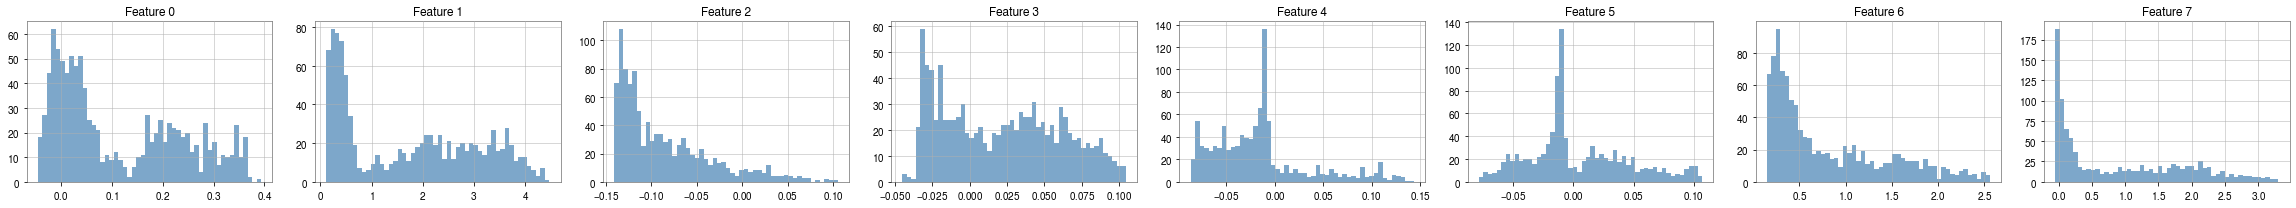

In [16]:
viz = AEVisualizer(network, device="cuda")

# Summarizer checks
features = viz.plot_feature_histograms(x_batch)        # histograms


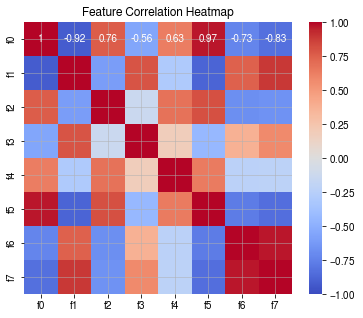

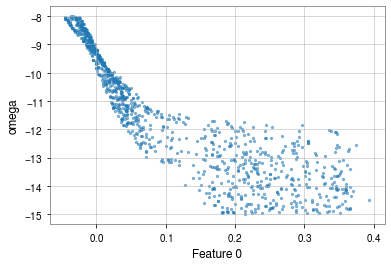

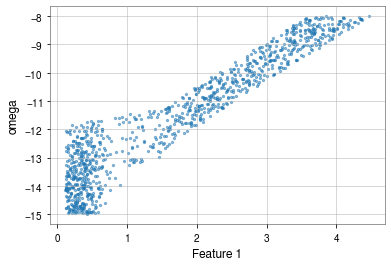

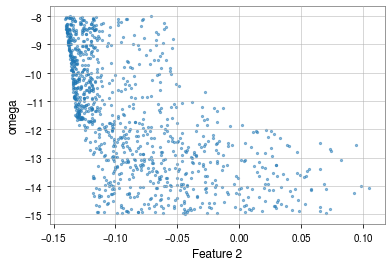

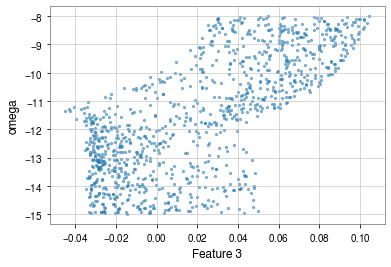

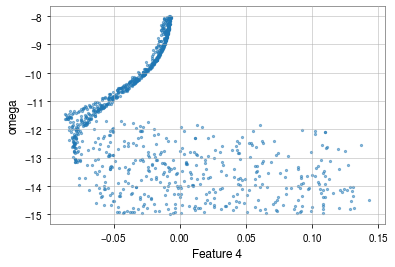

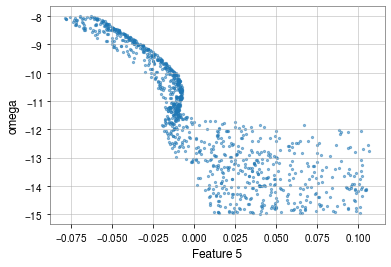

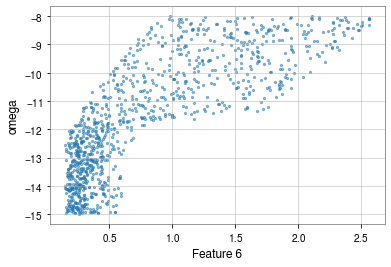

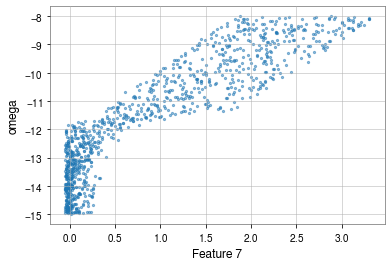

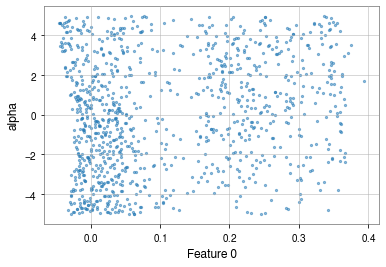

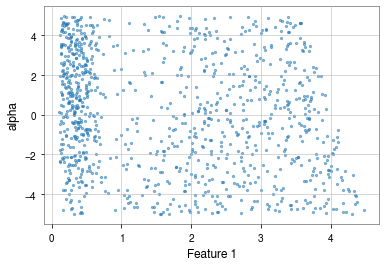

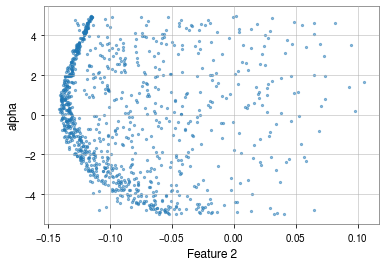

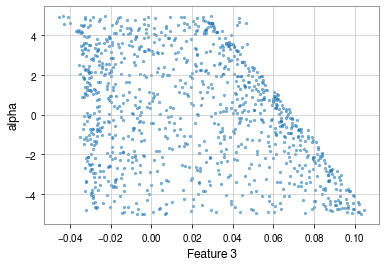

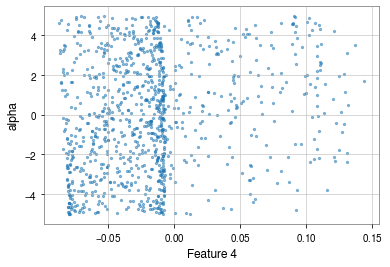

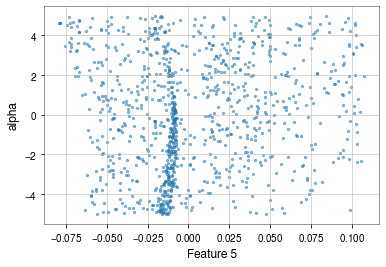

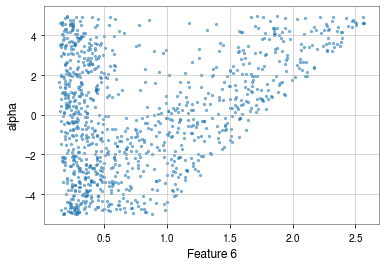

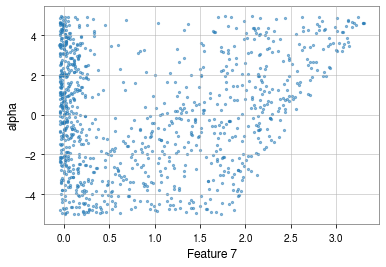

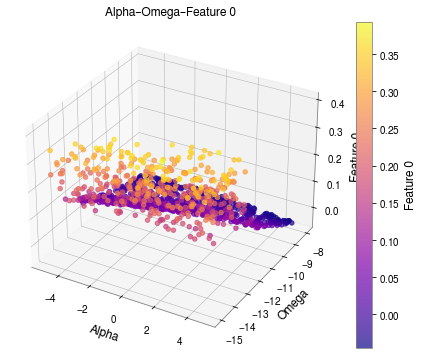

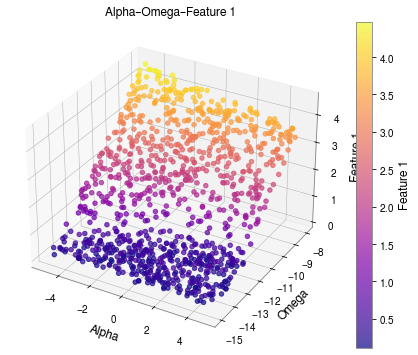

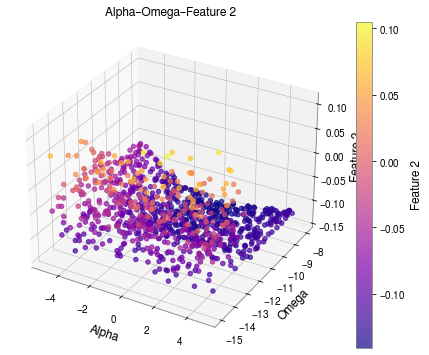

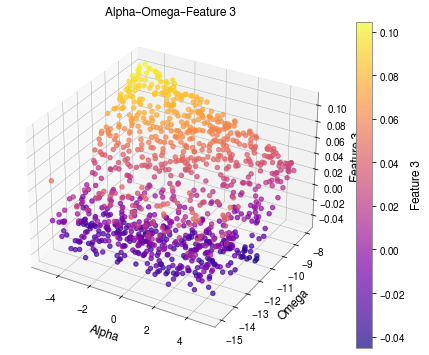

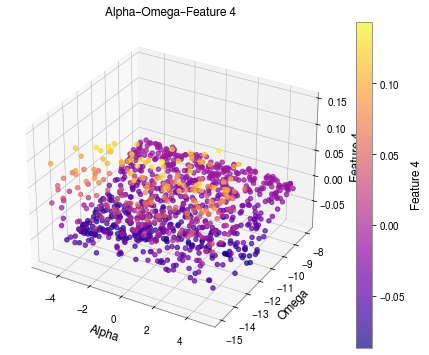

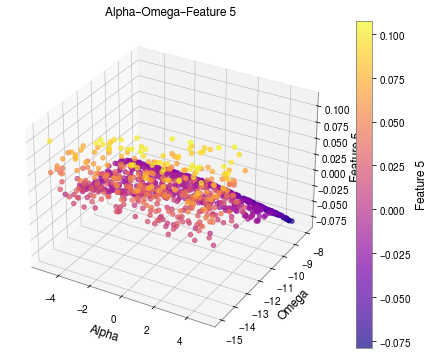

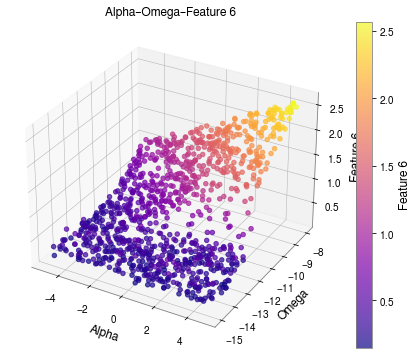

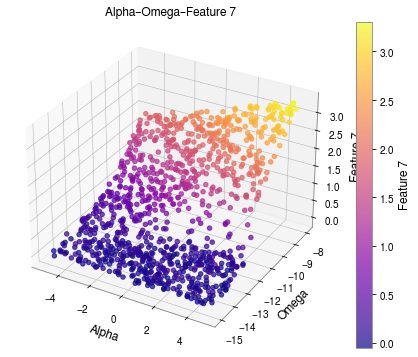

In [17]:
viz.plot_feature_correlation(features)                 # correlation
viz.plot_features_vs_params(features, z_batch)         # scatter vs params
viz.plot_3d_features(features, z_batch)         # scatter vs params

## Perform inference and collect bounds

### Positive alpha

In [18]:

predictions = trainer.infer(network, pos_test_data, prior_samples)
new_bounds = swyft.collect_rect_bounds(predictions[1], 'z', parshape=(2,), threshold=1e-3)
    
omega_prior = stats.uniform(new_bounds[0][0], new_bounds[0][1]-new_bounds[0][0]) 
alpha_prior = stats.uniform(new_bounds[1][0], new_bounds[1][1]-new_bounds[1][0]) 
    
pos_prior_samples = swyft.Samples(z = np.column_stack((omega_prior.rvs(500000), alpha_prior.rvs(500000))))
predictions = trainer.infer(network, pos_test_data, pos_prior_samples)

bounds = swyft.collect_rect_bounds(predictions[1], 'z', parshape=(2,), threshold=1e-3)
pos_samples_rounds.append(sims)
pos_bounds_rounds.append(bounds)
pos_predictions_rounds.append(predictions)
print(bounds)

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0:   3%|▌                  | 3/98 [00:00<00:01, 71.27it/s]

/home/lexi.leali/.conda/envs/SBI_env/lib/python3.11/site-packages/pytorch_lightning/loops/epoch/prediction_epoch_loop.py:173: UserWarning: Lightning couldn't infer the indices fetched for your dataloader.
  warning_cache.warn("Lightning couldn't infer the indices fetched for your dataloader.")


Predicting DataLoader 0: 100%|██████████████████| 98/98 [00:01<00:00, 85.56it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|████████████████| 489/489 [00:06<00:00, 73.90it/s]
tensor([[-8.6176, -8.3768],
        [ 1.1496,  1.8025]], dtype=torch.float64)


### negative alpha

In [19]:

predictions = trainer.infer(network, neg_test_data, prior_samples)
new_bounds = swyft.collect_rect_bounds(predictions[1], 'z', parshape=(2,), threshold=1e-3)
    
omega_prior = stats.uniform(new_bounds[0][0], new_bounds[0][1]-new_bounds[0][0]) 
alpha_prior = stats.uniform(new_bounds[1][0], new_bounds[1][1]-new_bounds[1][0]) 
    
neg_prior_samples = swyft.Samples(z = np.column_stack((omega_prior.rvs(500000), alpha_prior.rvs(500000))))
predictions = trainer.infer(network, neg_test_data, neg_prior_samples)

bounds = swyft.collect_rect_bounds(predictions[1], 'z', parshape=(2,), threshold=1e-3)
neg_samples_rounds.append(sims)
neg_bounds_rounds.append(bounds)
neg_predictions_rounds.append(predictions)
print(neg_bounds_rounds[0])

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 98/98 [00:01<00:00, 61.16it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|████████████████| 489/489 [00:05<00:00, 88.57it/s]
tensor([[-8.6311, -8.3612],
        [-3.3206, -2.5391]], dtype=torch.float64)


### zero alpha

In [20]:
predictions = trainer.infer(network, zero_test_data, prior_samples)
new_bounds = swyft.collect_rect_bounds(predictions[1], 'z', parshape=(2,), threshold=1e-3)
    
omega_prior = stats.uniform(new_bounds[0][0], new_bounds[0][1]-new_bounds[0][0]) 
alpha_prior = stats.uniform(new_bounds[1][0], new_bounds[1][1]-new_bounds[1][0]) 
    
zero_prior_samples = swyft.Samples(z = np.column_stack((omega_prior.rvs(500000), alpha_prior.rvs(500000))))
predictions = trainer.infer(network, zero_test_data, zero_prior_samples)

bounds = swyft.collect_rect_bounds(predictions[1], 'z', parshape=(2,), threshold=1e-3)
zero_samples_rounds.append(sims)
zero_bounds_rounds.append(bounds)
zero_predictions_rounds.append(predictions)
print(bounds)

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 98/98 [00:01<00:00, 83.65it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|████████████████| 489/489 [00:05<00:00, 84.99it/s]
tensor([[-8.6084, -8.3864],
        [-0.2786,  0.3442]], dtype=torch.float64)


### no signal 

In [21]:
predictions = trainer.infer(network, no_signal_test_data, prior_samples)
new_bounds = swyft.collect_rect_bounds(predictions[1], 'z', parshape=(2,), threshold=1e-3)
    
omega_prior = stats.uniform(new_bounds[0][0], new_bounds[0][1]-new_bounds[0][0]) 
alpha_prior = stats.uniform(new_bounds[1][0], new_bounds[1][1]-new_bounds[1][0]) 
    
no_signal_prior_samples = swyft.Samples(z = np.column_stack((omega_prior.rvs(500000), alpha_prior.rvs(500000))))
predictions = trainer.infer(network, no_signal_test_data, no_signal_prior_samples)

bounds = new_bounds
noise_samples_rounds.append(sims)
noise_bounds_rounds.append(bounds)
noise_predictions_rounds.append(predictions)

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 98/98 [00:01<00:00, 91.64it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|████████████████| 489/489 [00:05<00:00, 82.30it/s]


### Pickle and save

In [22]:
data = {"neg_bounds": neg_bounds_rounds,
        "neg_samples": neg_samples_rounds, 
        "neg_predictions": neg_predictions_rounds, 
        "pos_bounds": pos_bounds_rounds,
        "pos_samples": pos_samples_rounds, 
        "pos_predictions": pos_predictions_rounds,
        "zero_bounds": zero_bounds_rounds,
        "zero_samples": zero_samples_rounds, 
        "zero_predictions": zero_predictions_rounds, 
        "noise_bounds": noise_bounds_rounds,
        "noise_samples": noise_samples_rounds, 
        "noise_predictions": noise_predictions_rounds
       }
df = pd.DataFrame(data)
pickle_file = "TMNRE_round_1.pkl"
df.to_pickle(pickle_file)



### Plot training  and volidation loss 

['lr-AdamW', 'train_loss', 'epoch', 'val_loss']


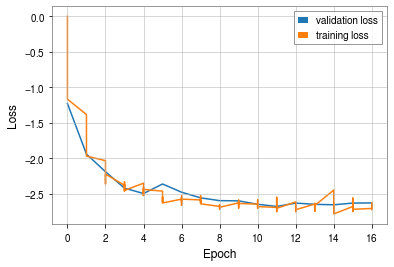

In [43]:
from tensorboard.backend.event_processing import event_accumulator
ea = event_accumulator.EventAccumulator("/scratch/lexi.leali/logs/AE_logs/version_299/events.out.tfevents.1759154102.ldas-pcdev12.243334.0")
ea.Reload()
print(ea.Tags()['scalars'])
training_loss_data = ea.Scalars('train_loss')
validation_loss_data = ea.Scalars('val_loss')
epoch_data = ea.Scalars('epoch')

train_epoch_hist = []
val_epoch_hist = []
epoch_hist = []
epoch_step = []
train_loss_hist = []
val_loss_hist = []

for entry in epoch_data: 
    epoch_step.append(entry.step)
    epoch_hist.append(entry.value)
    
epoch_step = np.array(epoch_step)
epoch_hist = np.array(epoch_hist)

for entry in training_loss_data:
    train_epoch_hist.append(epoch_hist[np.where(entry.step == epoch_step)][-1])
    train_loss_hist.append(entry.value)

for entry in validation_loss_data:
    val_epoch_hist.append(epoch_hist[np.where(entry.step == epoch_step)][-1])
    val_loss_hist.append(entry.value)

plt.plot(val_epoch_hist, val_loss_hist, label = 'validation loss')
plt.plot(train_epoch_hist, train_loss_hist, label = 'training loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Round one posteriors

### alpha = 3/2

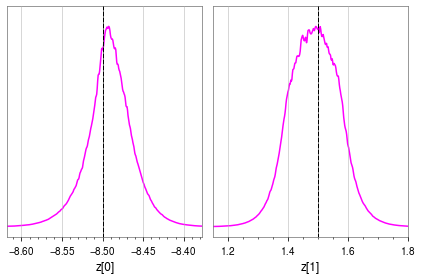

In [23]:
#truncated posteriors
truth = {k: v for k, v in zip(["z[%i]"%i for i in range(2)], pos_test_data['z'])}
colors = ['fuchsia', 'cyan', 'goldenrod', 'red', 'green']
fig = None
for i in range(1):
    fig = swyft.plot_posterior(pos_predictions_rounds[i], ["z[%i]"%i for i in range(2)], fig=fig, truth=truth, smooth = 1, bins = 400, contours = False, color=colors[i])

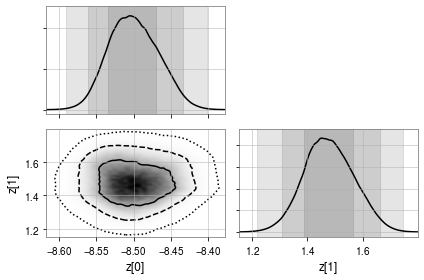

In [24]:
predictions = pos_predictions_rounds[0]
swyft.plot_corner(predictions[1], ["z[0]", "z[1]"], bins = 100, smooth = 1);

In [25]:

# Sample 1000 points from the priors
z_omega = omega_prior.rvs(1000)
z_alpha = alpha_prior.rvs(1000)
z_samps = np.column_stack((z_omega, z_alpha))
prior_samples = swyft.Samples(z = z_samps)

test_sims = sim.sample(N = 1000)
test_sims['x'] = preprocess_whiten(test_sims['x'] , sigma)
coverage_samples = trainer.test_coverage(network, test_sims[-1000:], prior_samples[:])

100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 768.52it/s]
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 32/32 [00:02<00:00, 13.21it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]



Predicting DataLoader 0: 100%|██████████████| 1000/1000 [00:12<00:00, 79.11it/s]


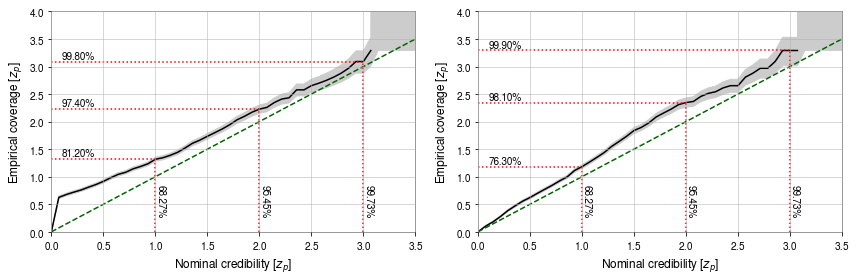

In [26]:
fix, axes = plt.subplots(1, 2, figsize = (12, 4))
for i in range(2):
    swyft.plot_zz(coverage_samples, "z[%i]"%i, ax = axes[i])
plt.tight_layout()
plt.show()

In [27]:
z_omega = omega_prior.rvs(100000)
z_alpha = alpha_prior.rvs(100000)

z_samps = np.column_stack((z_omega, z_alpha))

# Create prior samples
prior_samples = swyft.Samples(z = z_samps)
predictions = trainer.infer(network, pos_test_data, prior_samples)


ln_r = np.asarray(predictions[1].logratios)
r = np.exp(ln_r).reshape([-1])

post_idx = np.random.choice(np.arange(0, 100000, 1), size=5000, p = r/np.sum(r))
post_Omega = z_samps[post_idx, 0]
post_alpha = z_samps[post_idx, 1]
print(np.std(10**post_Omega), np.std(post_alpha))


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|█████████████████| 98/98 [00:00<00:00, 100.63it/s]
1.5702736342059142e-12 2.799910058554025


### Negative alpha

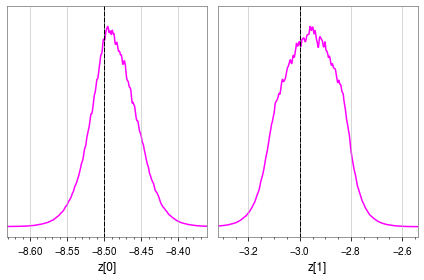

In [28]:
#truncated posteriors
truth = {k: v for k, v in zip(["z[%i]"%i for i in range(2)], neg_test_data['z'])}
colors = ['fuchsia', 'cyan', 'goldenrod', 'red', 'green']
fig = None
for i in range(1):
    fig = swyft.plot_posterior(neg_predictions_rounds[i], ["z[%i]"%i for i in range(2)], fig=fig, truth=truth, smooth = 1, bins = 400, contours = False, color=colors[i])

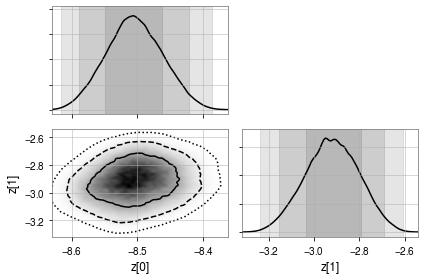

In [29]:
predictions = neg_predictions_rounds[0]
swyft.plot_corner(predictions[1], ["z[0]", "z[1]"], bins = 100, smooth = 1);

In [30]:

# Sample 1000 points from the priors
z_omega = omega_prior.rvs(1000)
z_alpha = alpha_prior.rvs(1000)
z_samps = np.column_stack((z_omega, z_alpha))
prior_samples = swyft.Samples(z = z_samps)

sims = sim.sample(N = 1000)
sims['x'] = preprocess_whiten(sims['x'] , sigma)
coverage_samples = trainer.test_coverage(network, sims[-1000:], prior_samples[:])

100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 899.47it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 32/32 [00:00<00:00, 84.15it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████| 1000/1000 [00:12<00:00, 79.07it/s]


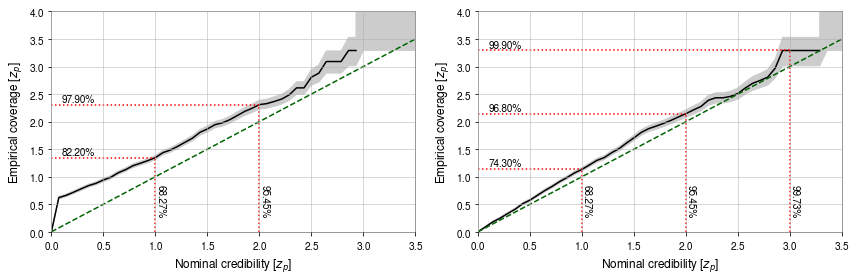

In [31]:
fix, axes = plt.subplots(1, 2, figsize = (12, 4))
for i in range(2):
    swyft.plot_zz(coverage_samples, "z[%i]"%i, ax = axes[i])
plt.tight_layout()
plt.show()

In [32]:
z_omega = omega_prior.rvs(100000)
z_alpha = alpha_prior.rvs(100000)

z_samps = np.column_stack((z_omega, z_alpha))

# Create prior samples
prior_samples = swyft.Samples(z = z_samps)
predictions = trainer.infer(network, pos_test_data, prior_samples)


ln_r = np.asarray(predictions[1].logratios)
r = np.exp(ln_r).reshape([-1])

post_idx = np.random.choice(np.arange(0, 100000, 1), size=5000, p = r/np.sum(r))
post_Omega = z_samps[post_idx, 0]
post_alpha = z_samps[post_idx, 1]
print(np.std(10**post_Omega), np.std(post_alpha))


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 98/98 [00:01<00:00, 82.18it/s]
1.630958474168999e-12 2.8173122786357334


### alpha = 0

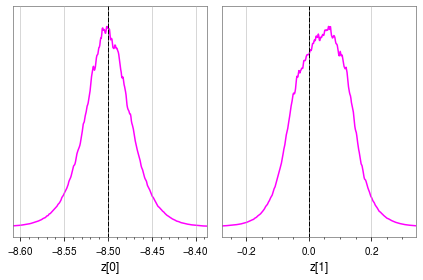

In [33]:
#truncated posteriors
truth = {k: v for k, v in zip(["z[%i]"%i for i in range(2)], zero_test_data['z'])}
colors = ['fuchsia', 'cyan', 'goldenrod', 'red', 'green']
fig = None
for i in range(1):
    fig = swyft.plot_posterior(zero_predictions_rounds[i], ["z[%i]"%i for i in range(2)], fig=fig, truth=truth, smooth = 1, bins = 400, contours = False, color=colors[i])

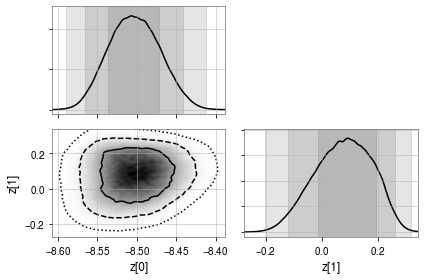

In [34]:
predictions = zero_predictions_rounds[0]
swyft.plot_corner(predictions[1], ["z[0]", "z[1]"], bins = 100, smooth = 1);

In [35]:

# Sample 1000 points from the priors
z_omega = omega_prior.rvs(1000)
z_alpha = alpha_prior.rvs(1000)
z_samps = np.column_stack((z_omega, z_alpha))
prior_samples = swyft.Samples(z = z_samps)

sims = sim.sample(N = 1000)
sims['x'] = preprocess_whiten(sims['x'] , sigma)
coverage_samples = trainer.test_coverage(network, sims[-1000:], prior_samples[:])

100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 921.63it/s]
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 32/32 [00:00<00:00, 97.86it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████| 1000/1000 [00:12<00:00, 78.13it/s]


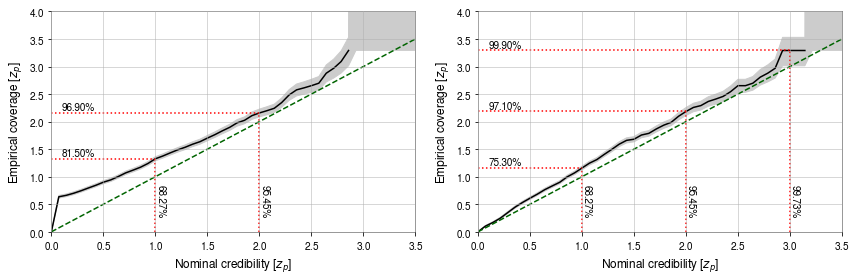

In [36]:
fix, axes = plt.subplots(1, 2, figsize = (12, 4))
for i in range(2):
    swyft.plot_zz(coverage_samples, "z[%i]"%i, ax = axes[i])
plt.tight_layout()
plt.show()

In [37]:
z_omega = omega_prior.rvs(100000)
z_alpha = alpha_prior.rvs(100000)

z_samps = np.column_stack((z_omega, z_alpha))

# Create prior samples
prior_samples = swyft.Samples(z = z_samps)
predictions = trainer.infer(network, pos_test_data, prior_samples)


ln_r = np.asarray(predictions[1].logratios)
r = np.exp(ln_r).reshape([-1])

post_idx = np.random.choice(np.arange(0, 100000, 1), size=5000, p = r/np.sum(r))
post_Omega = z_samps[post_idx, 0]
post_alpha = z_samps[post_idx, 1]
print(np.std(10**post_Omega), np.std(post_alpha))


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 98/98 [00:01<00:00, 57.33it/s]
1.5732909504782398e-12 2.822229347838341


### Noise only

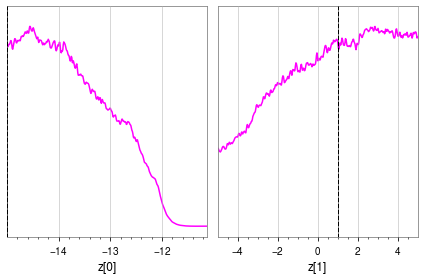

In [38]:
#truncated posteriors
truth = {k: v for k, v in zip(["z[%i]"%i for i in range(2)], no_signal_test_data['z'])}
colors = ['fuchsia', 'cyan', 'goldenrod', 'red', 'green']
fig = None
for i in range(1):
    fig = swyft.plot_posterior(noise_predictions_rounds[i], ["z[%i]"%i for i in range(2)], fig=fig, truth=truth, smooth = 1, bins = 400, contours = False, color=colors[i])

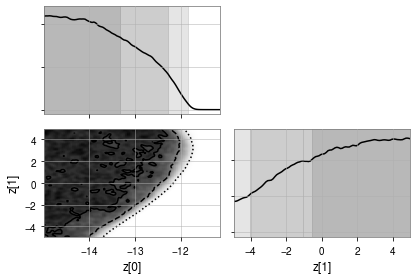

In [39]:
predictions = noise_predictions_rounds[0]
swyft.plot_corner(predictions[1], ["z[0]", "z[1]"], bins = 100, smooth = 1);

In [40]:

# Sample 1000 points from the priors
z_omega = omega_prior.rvs(1000)
z_alpha = alpha_prior.rvs(1000)
z_samps = np.column_stack((z_omega, z_alpha))
prior_samples = swyft.Samples(z = z_samps)

sims = sim.sample(N = 1000)
sims['x'] = preprocess_whiten(sims['x'] , sigma)
coverage_samples = trainer.test_coverage(network, sims[-1000:], prior_samples[:])

100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 888.57it/s]
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 32/32 [00:00<00:00, 58.74it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████| 1000/1000 [00:12<00:00, 79.43it/s]


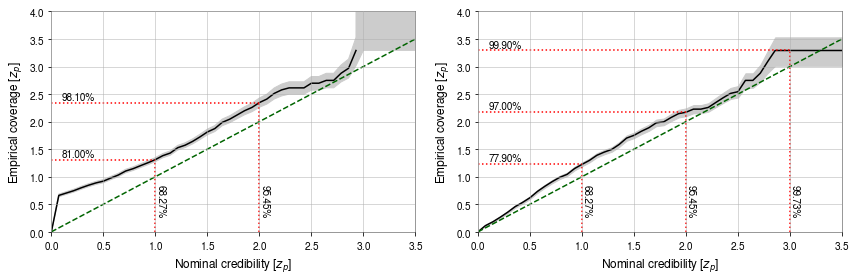

In [41]:
fix, axes = plt.subplots(1, 2, figsize = (12, 4))
for i in range(2):
    swyft.plot_zz(coverage_samples, "z[%i]"%i, ax = axes[i])
plt.tight_layout()
plt.show()

In [42]:
z_omega = omega_prior.rvs(100000)
z_alpha = alpha_prior.rvs(100000)

z_samps = np.column_stack((z_omega, z_alpha))

# Create prior samples
prior_samples = swyft.Samples(z = z_samps)
predictions = trainer.infer(network, pos_test_data, prior_samples)


ln_r = np.asarray(predictions[1].logratios)
r = np.exp(ln_r).reshape([-1])

post_idx = np.random.choice(np.arange(0, 100000, 1), size=5000, p = r/np.sum(r))
post_Omega = z_samps[post_idx, 0]
post_alpha = z_samps[post_idx, 1]
print(np.std(10**post_Omega), np.std(post_alpha))


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting DataLoader 0: 100%|██████████████████| 98/98 [00:01<00:00, 66.12it/s]
1.6124518668366225e-12 2.808053992458528
